In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [4]:
train_dir = "maskdata/train"
test_dir = "maskdata/test"

In [5]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [6]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'
)

Found 616 images belonging to 2 classes.
Found 198 images belonging to 2 classes.


In [15]:
print(train_data.class_indices)

{'with_mask': 0, 'without_mask': 1}


ANN Model

In [7]:
ann = models.Sequential([
    layers.Flatten(input_shape=(128,128,3)),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

ann.compile(optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy'])

history_ann = ann.fit(train_data, validation_data=test_data, epochs=5)

c:\Users\Hend\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 366ms/step - accuracy: 0.5227 - loss: 9.9900 - val_accuracy: 0.6717 - val_loss: 3.9143
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 352ms/step - accuracy: 0.7240 - loss: 1.1340 - val_accuracy: 0.6465 - val_loss: 0.8179
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 364ms/step - accuracy: 0.8231 - loss: 0.4187 - val_accuracy: 0.8687 - val_loss: 0.3313
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 341ms/step - accuracy: 0.8685 - loss: 0.2860 - val_accuracy: 0.7323 - val_loss: 0.5834
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 349ms/step - accuracy: 0.8198 - loss: 0.4227 - val_accuracy: 0.5657 - val_loss: 1.0087


CNN Model

In [8]:
cnn = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

cnn.compile(optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy'])

history_cnn = cnn.fit(train_data, validation_data=test_data, epochs=5)

c:\Users\Hend\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 448ms/step - accuracy: 0.5276 - loss: 0.7477 - val_accuracy: 0.3333 - val_loss: 0.7941
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 441ms/step - accuracy: 0.7825 - loss: 0.4730 - val_accuracy: 0.8788 - val_loss: 0.3644
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 405ms/step - accuracy: 0.9205 - loss: 0.2163 - val_accuracy: 0.9343 - val_loss: 0.1889
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 396ms/step - accuracy: 0.9464 - loss: 0.1608 - val_accuracy: 0.9444 - val_loss: 0.1389
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 408ms/step - accuracy: 0.9562 - loss: 0.1205 - val_accuracy: 0.9747 - val_loss: 0.0824


Transfare Model

In [9]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128,128,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [10]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

In [11]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history_tl = model.fit(train_data,
                        validation_data=test_data,
                        epochs=5)

Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 528ms/step - accuracy: 0.9497 - loss: 0.1151 - val_accuracy: 0.9899 - val_loss: 0.0438
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 405ms/step - accuracy: 0.9935 - loss: 0.0150 - val_accuracy: 0.9899 - val_loss: 0.0270
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 419ms/step - accuracy: 0.9935 - loss: 0.0244 - val_accuracy: 0.9848 - val_loss: 0.0236
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 392ms/step - accuracy: 0.9951 - loss: 0.0179 - val_accuracy: 0.9848 - val_loss: 0.0549
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 450ms/step - accuracy: 0.9968 - loss: 0.0150 - val_accuracy: 0.9848 - val_loss: 0.0488


In [12]:
print("ANN Accuracy:", ann.evaluate(test_data))
print("CNN Accuracy:", cnn.evaluate(test_data))
print("Transfer Learning Accuracy:", model.evaluate(test_data))

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.5657 - loss: 1.0087
ANN Accuracy: [1.0087085962295532, 0.5656565427780151]
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - accuracy: 0.9747 - loss: 0.0824
CNN Accuracy: [0.08244272321462631, 0.9747474789619446]
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 214ms/step - accuracy: 0.9848 - loss: 0.0488
Transfer Learning Accuracy: [0.048753559589385986, 0.9848484992980957]


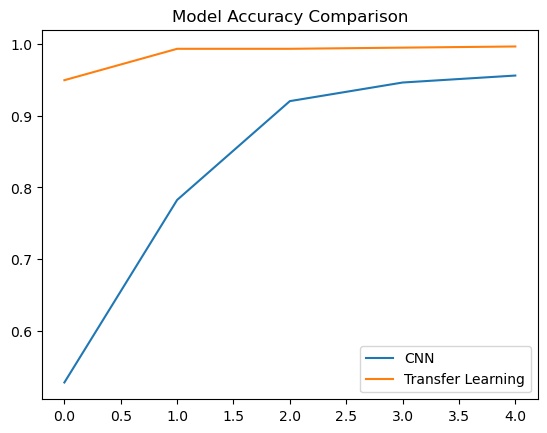

In [13]:
plt.plot(history_cnn.history['accuracy'], label='CNN')
plt.plot(history_tl.history['accuracy'], label='Transfer Learning')
plt.legend()
plt.title("Model Accuracy Comparison")
plt.show()